<a href="https://colab.research.google.com/github/MishaE-e/ml_fmi/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ельшин М.А.
Гуляев Г.Н.

группы ФМ/О РФЗ-1-2022 НБ

В качестве примера используется набор данныхо недвижимости в городах России. Данные можно посмотреть по ссылке https://www.kaggle.com/datasets/mrdaniilak/russia-real-estate-20182021. Из всего набора данных используются данные по Новороссийску.

Набор данных описывается следующими колонками

* date - дата публикации объявления;
* time - время публикации объявления;
* geo_lat - широта объекта недвижимости в градусах;
* geo_lon - долгота;
* region - код региона России (но с техническими правками).
* building_type - технология стройки: 0 - другая, 1 - панельный дом, 2 - монолитный каркас, 3 - кирпичный дом, 4 - блочный (газобетон, ПГП), 5 - деревянный;
* object_type - тип объекта: 1 - вторичный; 2 - первичная продажа от застройщика;
* level - этаж;
* levels - общее количество этажей в доме;
* rooms - количество жилых комнат: "-1" означает студию.
* area - общая площадь, кв.м.
* kitchen_area - площадь кухни, кв.м.
* price - цена, руб.

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

In [ ]:
df = pd.read_csv("all_v2.csv",parse_dates=['date'])
df

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
1,8650000,2018-02-27,12:04:54,55.683807,37.297405,81,3,5,24,2,69.1,12.0,1
2,4000000,2018-02-28,15:44:00,56.295250,44.061637,2871,1,5,9,3,66.0,10.0,1
3,1850000,2018-03-01,11:24:52,44.996132,39.074783,2843,4,12,16,2,38.0,5.0,11
4,5450000,2018-03-01,17:42:43,55.918767,37.984642,81,3,13,14,2,60.0,10.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5477001,19739760,2021-05-01,20:13:58,55.804736,37.750898,3,1,8,17,4,93.2,13.8,11
5477002,12503160,2021-05-01,20:14:01,55.841415,37.489624,3,2,17,32,2,45.9,6.6,11
5477003,8800000,2021-05-01,20:14:04,56.283909,44.075408,2871,2,4,17,3,86.5,11.8,1
5477004,11831910,2021-05-01,20:14:12,55.804736,37.750898,3,1,8,33,2,52.1,18.9,11


Фильтор по координатам города (Пермь)

In [ ]:
df_n = df[
    (df["geo_lat"] >= 57.95) & (df["geo_lat"] <= 58.10) &
    (df["geo_lon"] >= 56.15) & (df["geo_lon"] <= 56.35)
]

print("Отфильтрованные данные:\n", df_n)

Отфильтрованные данные:
            price       date      time    geo_lat    geo_lon  region  \
55       2500000 2018-04-30  19:14:08  57.989700  56.193996    5520   
302      1800000 2018-09-08  00:54:05  57.956856  56.241176    5520   
927      1898950 2018-09-08  01:56:19  57.995497  56.204252    5520   
2216     1780000 2018-09-08  10:18:34  58.022902  56.296179    5520   
2363     1800000 2018-09-08  10:56:56  57.973163  56.206817    5520   
...          ...        ...       ...        ...        ...     ...   
5473994  3430000 2021-05-01  15:14:22  57.973760  56.202536    5520   
5474002  2850000 2021-05-01  15:15:20  58.000412  56.174108    5520   
5474185  2200000 2021-05-01  15:40:24  57.987413  56.254004    5520   
5475650  3120000 2021-05-01  17:09:29  57.967145  56.268701    5520   
5476907  8600000 2021-05-01  19:55:41  58.000515  56.245642    5520   

         building_type  level  levels  rooms  area  kitchen_area  object_type  
55                   3      3       5     

Фильтор по дате (2021 год)

In [ ]:
from datetime import datetime
date2020 = datetime(2021, 1, 1)
date2022 = datetime(2021, 12, 31)
df_n = df_n[(df_n["date"]>=date2020) & (df_n["date"]<=date2022)]
df_n

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
4911407,3508670,2021-01-01,07:22:00,58.035540,56.255823,5520,2,1,4,1,42.0,17.0,11
4911408,3551255,2021-01-01,07:22:09,58.035540,56.255823,5520,2,1,4,1,42.0,17.0,11
4911409,4987125,2021-01-01,07:22:17,58.035540,56.255823,5520,2,4,4,2,60.0,20.0,11
4911410,3538015,2021-01-01,07:22:18,58.035540,56.255823,5520,2,4,4,1,41.0,17.0,11
4911411,3538015,2021-01-01,07:22:24,58.035540,56.255823,5520,2,2,4,1,41.0,17.0,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5473994,3430000,2021-05-01,15:14:22,57.973760,56.202536,5520,1,8,10,2,53.2,8.9,1
5474002,2850000,2021-05-01,15:15:20,58.000412,56.174108,5520,1,5,5,1,32.9,6.2,1
5474185,2200000,2021-05-01,15:40:24,57.987413,56.254004,5520,3,4,4,2,43.1,6.0,1
5475650,3120000,2021-05-01,17:09:29,57.967145,56.268701,5520,3,5,5,3,57.5,6.0,1


Карта города с метками недвижемости

In [ ]:
import folium

map_nyc = folium.Map(location=[58.010455, 56.229443], zoom_start=10)

for _, row in df_n.iterrows():
    folium.Marker(location=[row['geo_lat'], row['geo_lon']], popup=row['price']).add_to(map_nyc)

map_nyc

Вычисляется расстояние от центра города до каждой точки, который содержит данные о местоположении объектов. В итоге, в df_distance будет добавлен новый столбец, содержащий расстояния от центра

In [ ]:
xc = 58.010455
yc = 56.229443

In [ ]:
from math import sqrt

def distance(row):
    return sqrt((xc-row["geo_lat"])**2 + (yc-row["geo_lon"])**2)

df_distance = df_n.copy()

df_distance[""] = df_n.apply(lambda row: distance(row), axis=1)
df_distance

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type,
4911407,3508670,2021-01-01,07:22:00,58.035540,56.255823,5520,2,1,4,1,42.0,17.0,11,0.036403
4911408,3551255,2021-01-01,07:22:09,58.035540,56.255823,5520,2,1,4,1,42.0,17.0,11,0.036403
4911409,4987125,2021-01-01,07:22:17,58.035540,56.255823,5520,2,4,4,2,60.0,20.0,11,0.036403
4911410,3538015,2021-01-01,07:22:18,58.035540,56.255823,5520,2,4,4,1,41.0,17.0,11,0.036403
4911411,3538015,2021-01-01,07:22:24,58.035540,56.255823,5520,2,2,4,1,41.0,17.0,11,0.036403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5473994,3430000,2021-05-01,15:14:22,57.973760,56.202536,5520,1,8,10,2,53.2,8.9,1,0.045503
5474002,2850000,2021-05-01,15:15:20,58.000412,56.174108,5520,1,5,5,1,32.9,6.2,1,0.056239
5474185,2200000,2021-05-01,15:40:24,57.987413,56.254004,5520,3,4,4,2,43.1,6.0,1,0.033677
5475650,3120000,2021-05-01,17:09:29,57.967145,56.268701,5520,3,5,5,3,57.5,6.0,1,0.058455


Используем библиотеку geopy для вычисления расстояния между двумя точками

In [ ]:
from geopy import distance

def distance2(row):
    return distance.distance((xc, yc), (row["geo_lat"], row["geo_lon"])).km
    df_distance = df_n.copy()

In [ ]:
df_distance["distance"] = df_n.apply(lambda row: distance2(row), axis=1)
df_distance

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type,,distance
4911407,3508670,2021-01-01,07:22:00,58.035540,56.255823,5520,2,1,4,1,42.0,17.0,11,0.036403,3.199425
4911408,3551255,2021-01-01,07:22:09,58.035540,56.255823,5520,2,1,4,1,42.0,17.0,11,0.036403,3.199425
4911409,4987125,2021-01-01,07:22:17,58.035540,56.255823,5520,2,4,4,2,60.0,20.0,11,0.036403,3.199425
4911410,3538015,2021-01-01,07:22:18,58.035540,56.255823,5520,2,4,4,1,41.0,17.0,11,0.036403,3.199425
4911411,3538015,2021-01-01,07:22:24,58.035540,56.255823,5520,2,2,4,1,41.0,17.0,11,0.036403,3.199425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5473994,3430000,2021-05-01,15:14:22,57.973760,56.202536,5520,1,8,10,2,53.2,8.9,1,0.045503,4.385916
5474002,2850000,2021-05-01,15:15:20,58.000412,56.174108,5520,1,5,5,1,32.9,6.2,1,0.056239,3.457553
5474185,2200000,2021-05-01,15:40:24,57.987413,56.254004,5520,3,4,4,2,43.1,6.0,1,0.033677,2.948839
5475650,3120000,2021-05-01,17:09:29,57.967145,56.268701,5520,3,5,5,3,57.5,6.0,1,0.058455,5.353614


График распределения точек на карте в зависимости от их расстояния до центра.

<Axes: xlabel='Долгота, град', ylabel='Широта, град'>

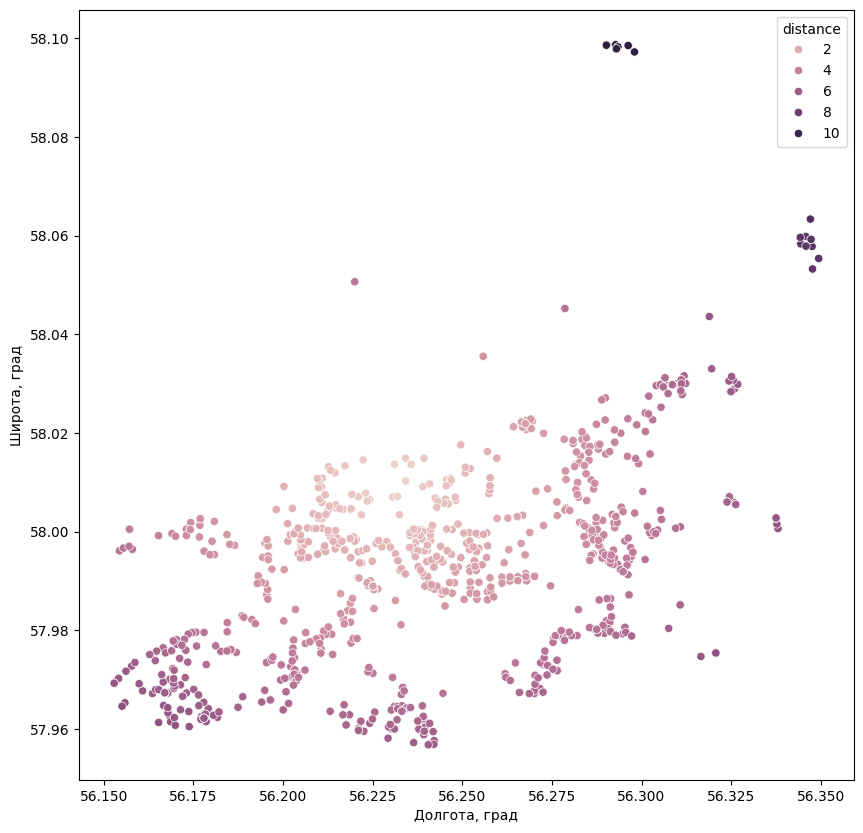

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
df_distance = df_distance.rename(columns={"geo_lon":"Долгота, град","geo_lat":"Широта, град"})
sns.scatterplot(data=df_distance, x="Долгота, град", y="Широта, град", hue = "distance")

Анали цены квартир на выбросы

<Axes: >

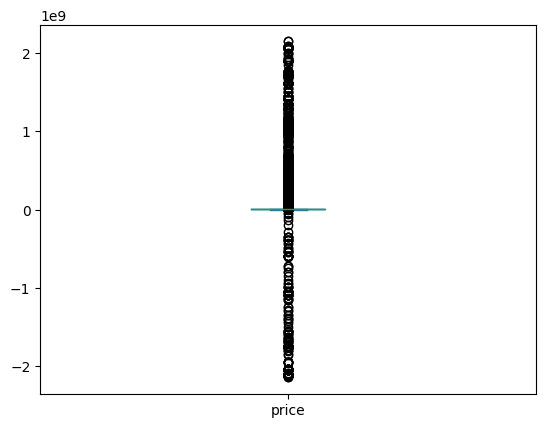

In [ ]:
df['price'].plot(kind='box')

Удаляем отрицательные цены и убераем выбросы

In [ ]:
import seaborn as sns
df_price = df_distance[(df_distance["price"]>=0) & (df_distance["price"]<=15000000)]
df_price = df_price.rename(columns={"geo_lon":"Долгота, град","geo_lat":"Широта, град", "price":"Цена, руб"})
df_price

,"Цена, руб",date,time,"Широта, град","Долгота, град",region,building_type,level,levels,rooms,area,kitchen_area,object_type,,distance
4911407,3508670,2021-01-01,07:22:00,58.035540,56.255823,5520,2,1,4,1,42.0,17.0,11,0.036403,3.199425
4911408,3551255,2021-01-01,07:22:09,58.035540,56.255823,5520,2,1,4,1,42.0,17.0,11,0.036403,3.199425
4911409,4987125,2021-01-01,07:22:17,58.035540,56.255823,5520,2,4,4,2,60.0,20.0,11,0.036403,3.199425
4911410,3538015,2021-01-01,07:22:18,58.035540,56.255823,5520,2,4,4,1,41.0,17.0,11,0.036403,3.199425
4911411,3538015,2021-01-01,07:22:24,58.035540,56.255823,5520,2,2,4,1,41.0,17.0,11,0.036403,3.199425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5473994,3430000,2021-05-01,15:14:22,57.973760,56.202536,5520,1,8,10,2,53.2,8.9,1,0.045503,4.385916
5474002,2850000,2021-05-01,15:15:20,58.000412,56.174108,5520,1,5,5,1,32.9,6.2,1,0.056239,3.457553
5474185,2200000,2021-05-01,15:40:24,57.987413,56.254004,5520,3,4,4,2,43.1,6.0,1,0.033677,2.948839
5475650,3120000,2021-05-01,17:09:29,57.967145,56.268701,5520,3,5,5,3,57.5,6.0,1,0.058455,5.353614


<Axes: >

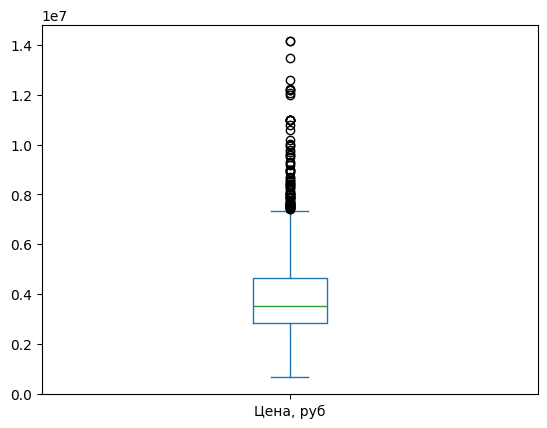

In [ ]:
df_price['Цена, руб'].plot(kind='box')

График, где каждая точка имеет координаты, а её цвет показывает стоимость

<Axes: xlabel='Долгота, град', ylabel='Широта, град'>

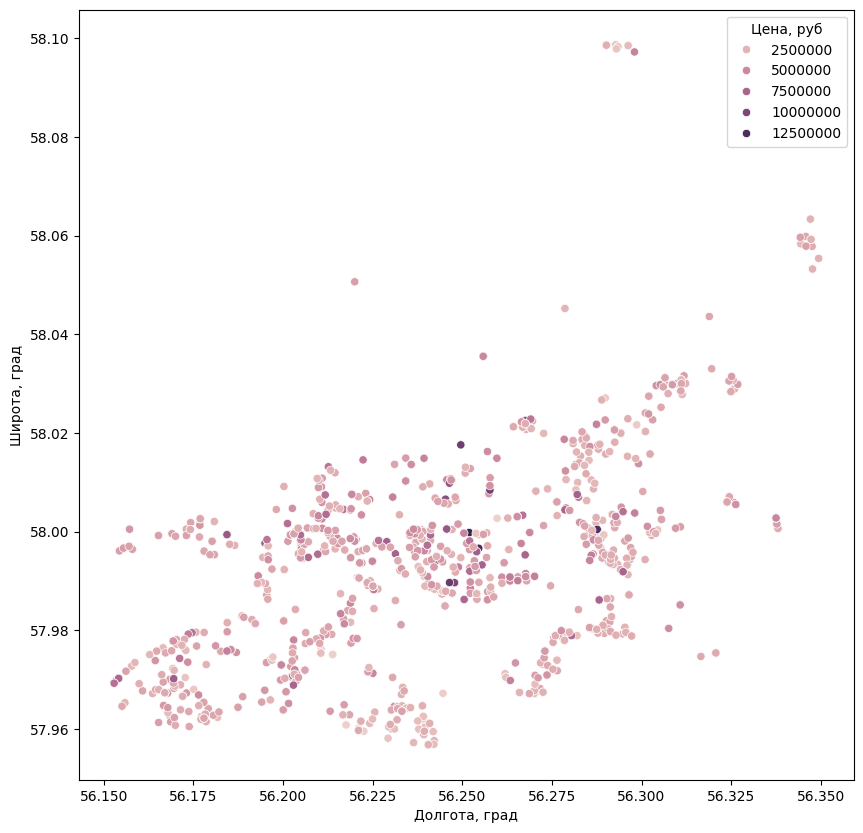

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.scatterplot(data=df_price, x="Долгота, град",y="Широта, град", hue = "Цена, руб")

Создаем столбчатые диаграммы, на которой по оси X отображается количество комнат, а цвет каждой колонки будет зависеть от типа здания. Это позволяет визуально сравнить распределение объектов недвижимости по количеству комнат и типам зданий

<Axes: xlabel='rooms', ylabel='count'>

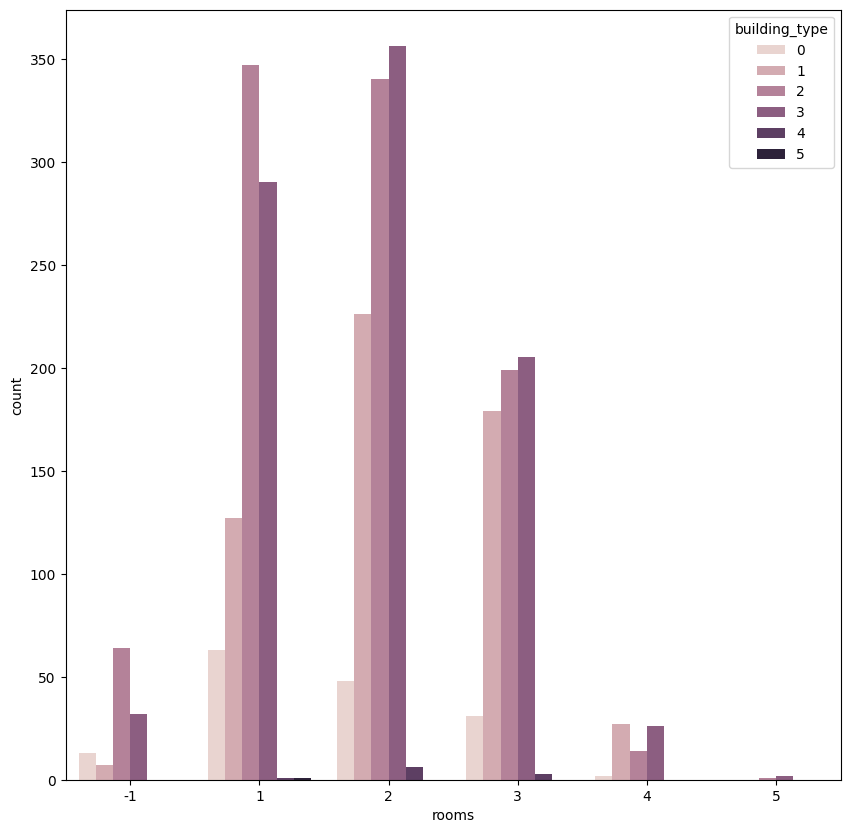

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.countplot (df_price, x="rooms", hue="building_type")

Вычисляем группу цен для каждого объекта недвижимости, разбивая цены на 10 равных диапазонов, и результат сохраняется в новом столбце "price_group"

In [ ]:
import math

df_price["Цена, руб"].max()

def price_group(row, count):
  value = 10000000/count
  return math.ceil(row["Цена, руб"]/value)*value

df_price["price_group"] = df_price.apply(lambda row: price_group(row, 10), axis=1)
df_price

,"Цена, руб",date,time,"Широта, град","Долгота, град",region,building_type,level,levels,rooms,area,kitchen_area,object_type,,distance,price_group
4911407,3508670,2021-01-01,07:22:00,58.035540,56.255823,5520,2,1,4,1,42.0,17.0,11,0.036403,3.199425,4000000.0
4911408,3551255,2021-01-01,07:22:09,58.035540,56.255823,5520,2,1,4,1,42.0,17.0,11,0.036403,3.199425,4000000.0
4911409,4987125,2021-01-01,07:22:17,58.035540,56.255823,5520,2,4,4,2,60.0,20.0,11,0.036403,3.199425,5000000.0
4911410,3538015,2021-01-01,07:22:18,58.035540,56.255823,5520,2,4,4,1,41.0,17.0,11,0.036403,3.199425,4000000.0
4911411,3538015,2021-01-01,07:22:24,58.035540,56.255823,5520,2,2,4,1,41.0,17.0,11,0.036403,3.199425,4000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5473994,3430000,2021-05-01,15:14:22,57.973760,56.202536,5520,1,8,10,2,53.2,8.9,1,0.045503,4.385916,4000000.0
5474002,2850000,2021-05-01,15:15:20,58.000412,56.174108,5520,1,5,5,1,32.9,6.2,1,0.056239,3.457553,3000000.0
5474185,2200000,2021-05-01,15:40:24,57.987413,56.254004,5520,3,4,4,2,43.1,6.0,1,0.033677,2.948839,3000000.0
5475650,3120000,2021-05-01,17:09:29,57.967145,56.268701,5520,3,5,5,3,57.5,6.0,1,0.058455,5.353614,4000000.0


In [ ]:
df_price.groupby(["price_group"]).count()

,"Цена, руб",date,time,"Широта, град","Долгота, град",region,building_type,level,levels,rooms,area,kitchen_area,object_type,,distance
price_group,,,,,,,,,,,,,,,
1000000.0,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
2000000.0,108,108,108,108,108,108,108,108,108,108,108,108,108,108,108
3000000.0,716,716,716,716,716,716,716,716,716,716,716,716,716,716,716
4000000.0,822,822,822,822,822,822,822,822,822,822,822,822,822,822,822
5000000.0,461,461,461,461,461,461,461,461,461,461,461,461,461,461,461
6000000.0,280,280,280,280,280,280,280,280,280,280,280,280,280,280,280
7000000.0,114,114,114,114,114,114,114,114,114,114,114,114,114,114,114
8000000.0,50,50,50,50,50,50,50,50,50,50,50,50,50,50,50
9000000.0,20,20,20,20,20,20,20,20,20,20,20,20,20,20,20


Строим столбчатую диаграмму, который отображает количество объектов в каждой ценовой группе, разделенных по типу здания.

<Axes: xlabel='price_group', ylabel='count'>

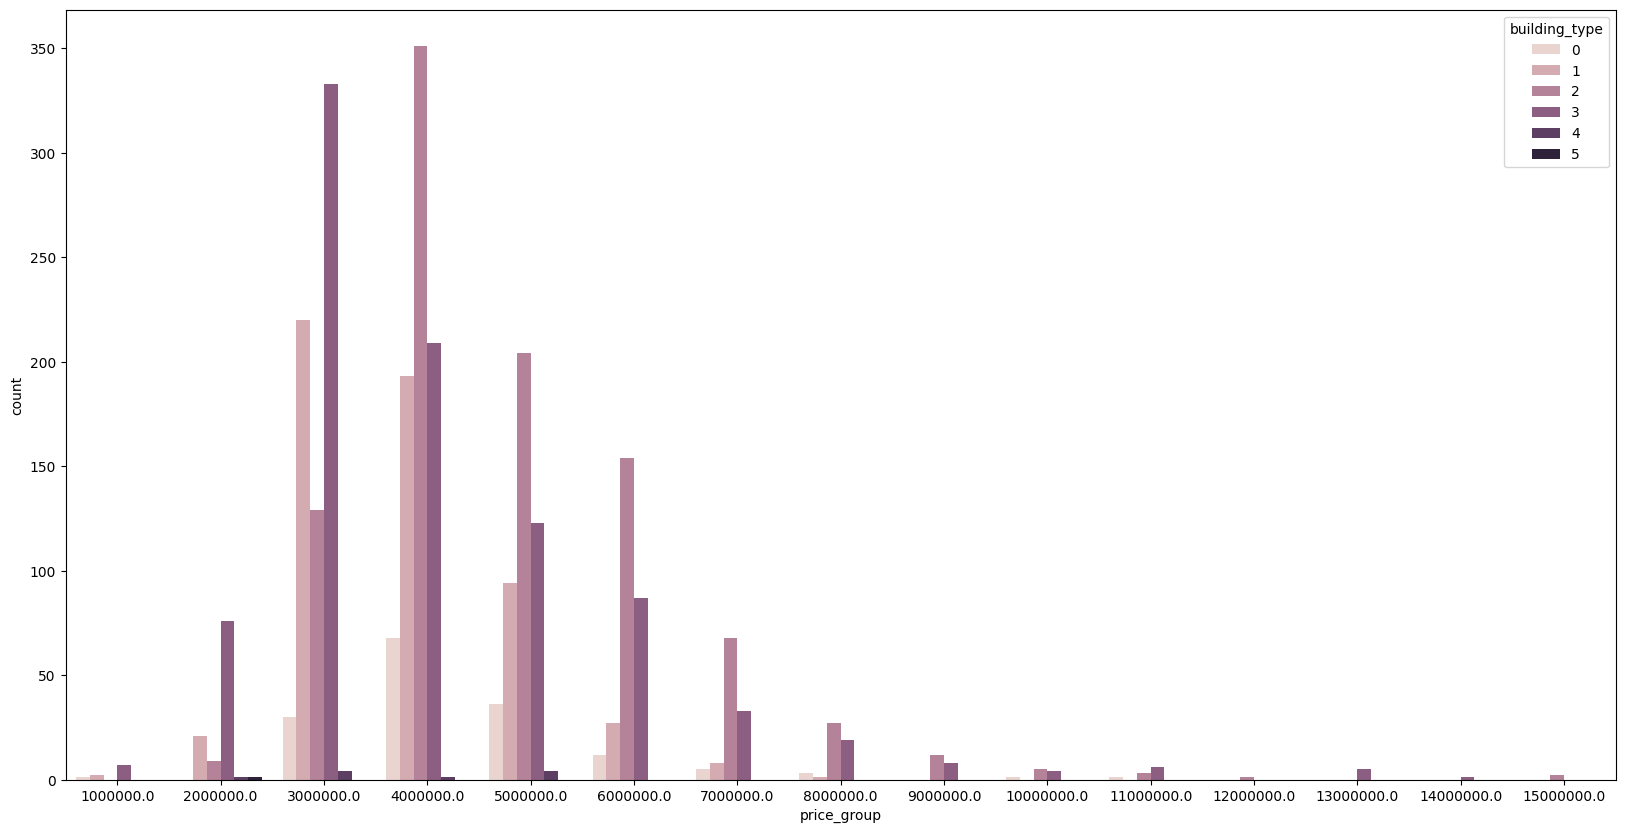

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10))
sns.countplot(data=df_price, x="price_group", hue="building_type", ax=ax)

Очищаем талбицу от времени

In [ ]:
df_n = df_price.drop(['time', 'region'], axis=1)

Проверка наличия пропусков.

In [ ]:
# Список долей отсутствующих данных
def out_na_percent(df):
    print(f"Всего записей: {len(df_n)}")
    for col in df.columns:
        pct_missing = np.mean(df_n[col].isna())
        print('{} - {}%'.format(col, round(pct_missing*10000)/100))

In [ ]:
out_na_percent(df_n)

Всего записей: 2610
Цена, руб - 0.0%
date - 0.0%
Широта, град - 0.0%
Долгота, град - 0.0%
building_type - 0.0%
level - 0.0%
levels - 0.0%
rooms - 0.0%
area - 0.0%
kitchen_area - 0.0%
object_type - 0.0%
 - 0.0%
distance - 0.0%
price_group - 0.0%


корреляционный анализ

In [ ]:
corr = df_n.corr()
corr.style.background_gradient(cmap='coolwarm')

,"Цена, руб",date,"Широта, град","Долгота, град",building_type,level,levels,rooms,area,kitchen_area,object_type,,distance,price_group
"Цена, руб",1.000000,0.083053,0.100311,-0.093152,0.012774,0.219881,0.280774,0.554266,0.790098,0.570106,0.186204,-0.184879,-0.216240,0.983452
date,0.083053,1.000000,0.097275,0.017793,-0.034810,0.014714,0.016580,0.020983,0.033722,0.043892,0.093873,-0.024840,-0.024681,0.077517
"Широта, град",0.100311,0.097275,1.000000,0.444224,0.081099,-0.080400,-0.077790,0.004387,0.081628,0.212892,0.338747,-0.087244,-0.220527,0.105755
"Долгота, град",-0.093152,0.017793,0.444224,1.000000,0.084832,-0.093405,-0.155848,0.011889,-0.014487,-0.034924,-0.126442,0.405727,0.254337,-0.089637
building_type,0.012774,-0.034810,0.081099,0.084832,1.000000,-0.122864,-0.184432,-0.026598,-0.006400,-0.013789,-0.176821,0.008684,-0.030916,0.015001
level,0.219881,0.014714,-0.080400,-0.093405,-0.122864,1.000000,0.654288,-0.033616,0.086615,0.164749,0.243473,-0.190675,-0.187490,0.222648
levels,0.280774,0.016580,-0.077790,-0.155848,-0.184432,0.654288,1.000000,-0.048480,0.136146,0.236639,0.364822,-0.311614,-0.319615,0.286970
rooms,0.554266,0.020983,0.004387,0.011889,-0.026598,-0.033616,-0.048480,1.000000,0.712307,0.238570,-0.086327,0.063958,0.038381,0.533555
area,0.790098,0.033722,0.081628,-0.014487,-0.006400,0.086615,0.136146,0.712307,1.000000,0.452460,0.069455,-0.070217,-0.098869,0.777132
kitchen_area,0.570106,0.043892,0.212892,-0.034924,-0.013789,0.164749,0.236639,0.238570,0.452460,1.000000,0.327772,-0.171505,-0.176641,0.565619


In [ ]:
df_n.describe()

,"Цена, руб",date,"Широта, град","Долгота, град",building_type,level,levels,rooms,area,kitchen_area,object_type,,distance,price_group
count,2.610000e+03,2610,2610.000000,2610.000000,2610.000000,2610.000000,2610.000000,2610.000000,2610.000000,2610.000000,2610.000000,2610.000000,2610.000000,2.610000e+03
mean,3.881072e+06,2021-03-16 04:59:02.068965376,58.001278,56.241643,2.020690,6.784291,12.609195,1.841762,52.704230,10.455605,5.628352,0.034533,2.689592,4.350958e+06
min,6.500000e+05,2021-01-01 00:00:00,57.956777,56.152857,0.000000,1.000000,1.000000,-1.000000,11.000000,1.200000,1.000000,0.003583,0.281765,1.000000e+06
25%,2.842400e+06,2021-02-20 06:00:00,57.988942,56.223527,1.000000,3.000000,5.000000,1.000000,40.000000,6.300000,1.000000,0.004764,0.282266,3.000000e+06
50%,3.508698e+06,2021-03-19 00:00:00,58.002741,56.234203,2.000000,5.000000,10.000000,2.000000,48.000000,9.600000,1.000000,0.030248,2.717773,4.000000e+06
75%,4.650000e+06,2021-04-11 00:00:00,58.010258,56.255823,3.000000,9.000000,19.000000,3.000000,62.000000,12.800000,11.000000,0.054272,4.346082,5.000000e+06
max,1.414900e+07,2021-05-01 00:00:00,58.098722,56.349418,5.000000,31.000000,31.000000,5.000000,427.000000,62.000000,11.000000,0.129011,10.575918,1.500000e+07
std,1.558651e+06,NaN,0.020786,0.035610,0.908392,5.554343,7.588380,1.022485,20.404085,4.960189,4.987124,0.027209,2.029946,1.576529e+06


Выбор признаков. Х - входные параметры, Y - цена, которую надо рассчитать.

In [ ]:
x = df_distance[["building_type", "level","levels","rooms","area","kitchen_area","object_type","distance"]]
y = df_distance['price']

Чтобы была возможность оценить качество моделей, делим исходные данные на обучающие и тестовые.

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

Линейные модели

In [ ]:
from sklearn import *

Простая линейная регрессия без оптимизации

In [ ]:
d=df_n[['area']]
k=df_n[['Цена, руб']]
d

,area
4911407,42.0
4911408,42.0
4911409,60.0
4911410,41.0
4911411,41.0
...,...
5473994,53.2
5474002,32.9
5474185,43.1
5475650,57.5


In [ ]:
model_LR = linear_model.LinearRegression()
model_LR.fit(d, k)

LinearRegression()

In [ ]:
yy_data_line= model_LR.predict(d)

In [ ]:
metrics.mean_squared_error(k,yy_data_line)

912483650039.431

In [ ]:
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


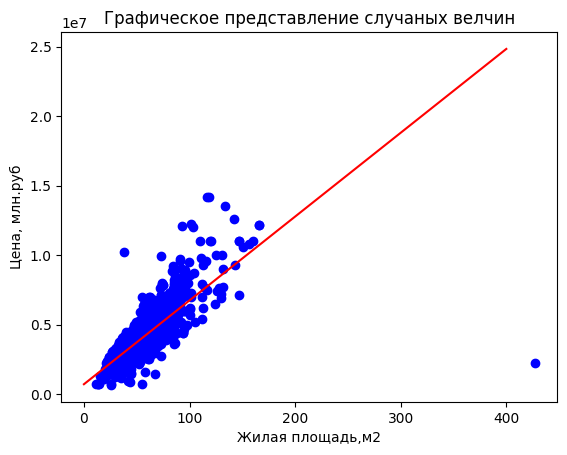

In [ ]:
xx = np.linspace(0, 400, num=2)
yy = model_LR.predict(xx.reshape(-1, 1))
plt.scatter(d,k, color='blue')
plt.xlabel('Жилая площадь,м2')
plt.ylabel('Цена, млн.руб')
plt.title("Графическое представление случаных велчин")
plt.plot(xx, yy, color='red')
plt.show()

Метод опорных векторов (SVM)

In [ ]:
model_SVM = svm.SVR(kernel='linear')

In [ ]:
model_SVM.fit(d, k)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR(kernel='linear')

In [ ]:
yy_pred_SVM = model_SVM.predict(xx.reshape(-1, 1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


In [ ]:
yy_data_SVM=model_SVM.predict(d)

In [ ]:
metrics.mean_squared_error(k, yy_data_SVM)

1469167062746.7725

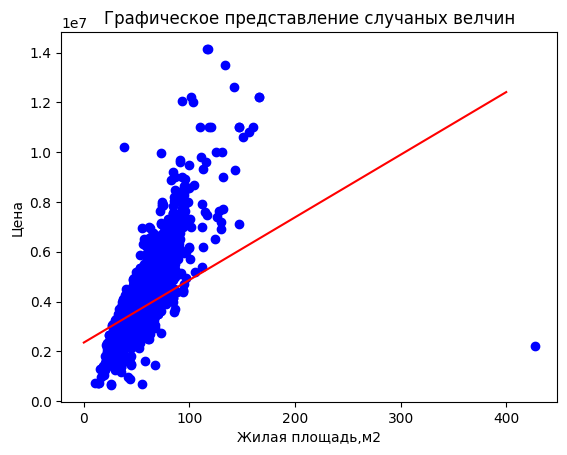

In [ ]:
xx = np.linspace(0, 400, num=2)
plt.scatter(d,k, color='blue')
plt.xlabel('Жилая площадь,м2')
plt.ylabel('Цена')
plt.title("Графическое представление случаных велчин")
plt.plot(xx, yy_pred_SVM, color='red')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


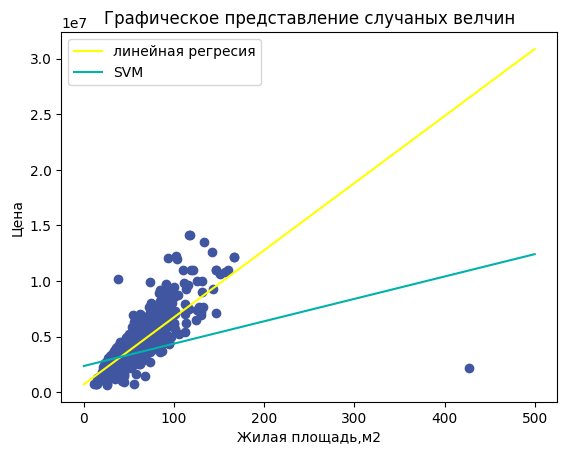

In [ ]:
xx = np.linspace(0, 500, num=2)
yy = model_LR.predict(xx.reshape(-1, 1))
plt.scatter(d, k, color='#4056a1')
plt.xlabel('Жилая площадь,м2')
plt.ylabel('Цена')
plt.title("Графическое представление случаных велчин")
plt.plot(xx, yy, color='#ffff00',label="линейная регресия")
plt.plot(xx, yy_pred_SVM, color='#00b2a9', label="SVM")
plt.legend()
plt.show()

Деревья решений

In [ ]:
model_tree = tree.DecisionTreeRegressor(max_depth=3)
model_tree.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=3)

In [ ]:
y_pred_tree = model_tree.predict(x_test)

In [ ]:
metrics.root_mean_squared_error(y_test, y_pred_tree)

992336.0836288763

In [ ]:
import matplotlib.pyplot as plt

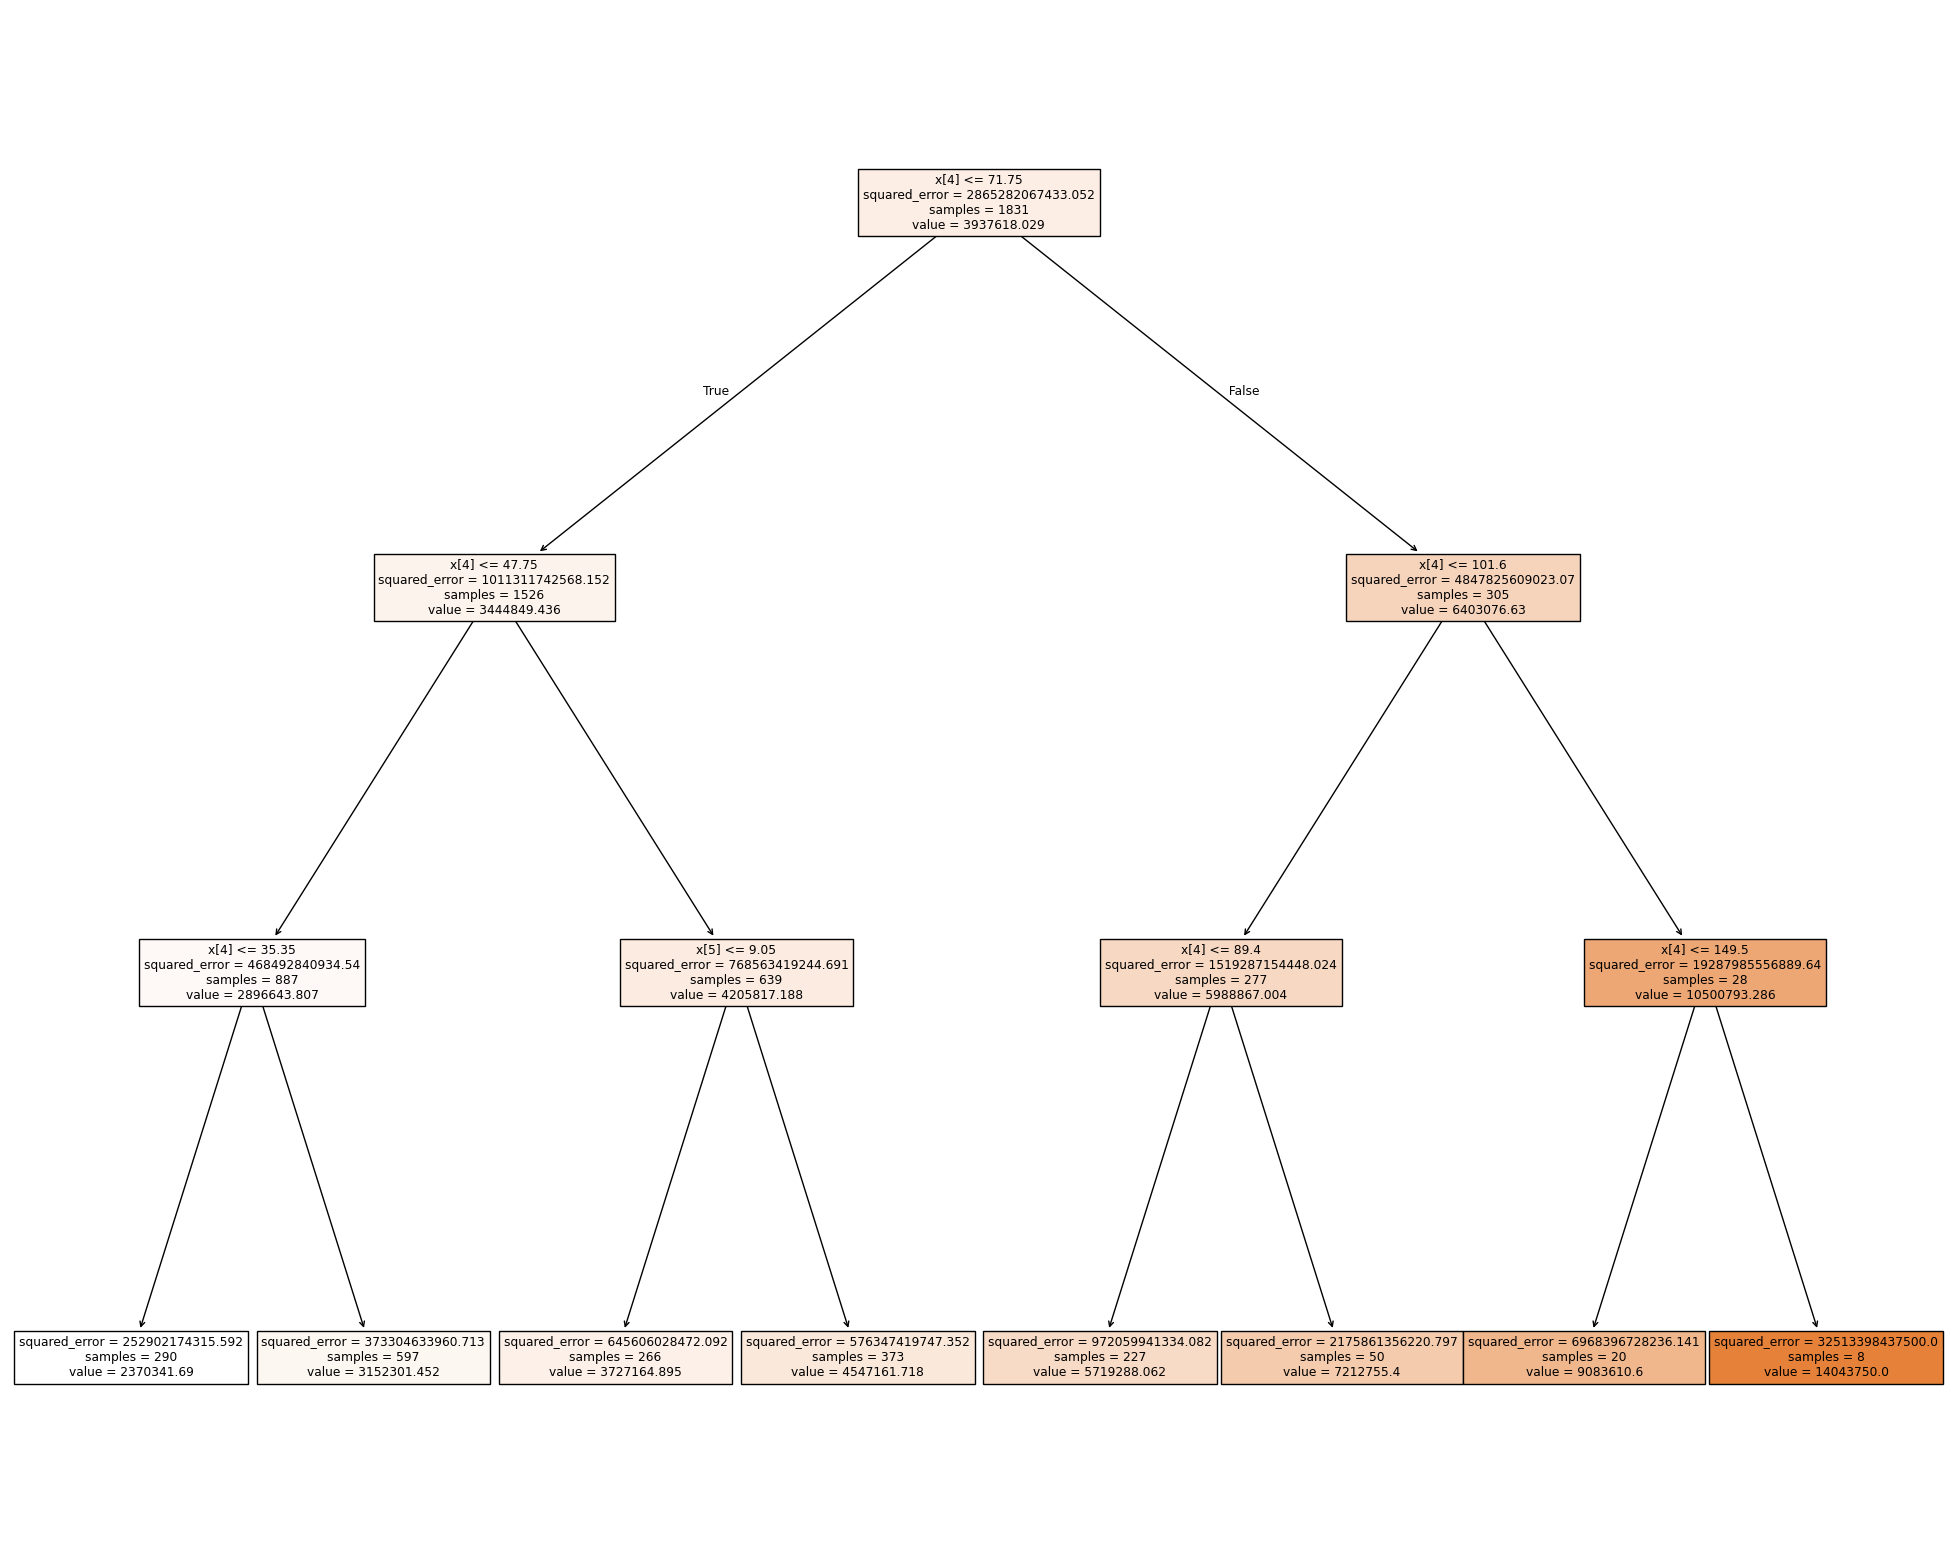

In [ ]:
_, ax = plt.subplots(figsize=(25,20))
tree.plot_tree(model_tree, filled=True, ax=ax)
plt.show()

Лес случайных деревьев

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model_rf = RandomForestRegressor(
    n_estimators=15,
    max_depth=50,
    random_state=3, bootstrap=True)
model_rf.fit(x_train,y_train)

RandomForestRegressor(max_depth=50, n_estimators=15, random_state=3)

In [ ]:
y_pred_rf = model_rf.predict(x_test)

In [ ]:
metrics.root_mean_squared_error(y_test, y_pred_rf)

819372.4847764985

Практическое использование

In [ ]:
a=model_rf.predict(pd.DataFrame([{
    'building_type':1,
    "level":5,
    "levels":9,
    "rooms":3,
    "area":68,
    "kitchen_area":10,
    "object_type":1,
    "distance":4.66,
    }]))
print("Цена квартиры:",round(a[0],2),'руб')

Цена квартиры: 3999624.93 руб


Стоимость квартиры с учетом инфляции примерно 6 мил руб

Калькулятор инфляции: https://уровень-инфляции.рф/инфляционные-калькуляторы

реальная стоймость квартиры: 5.8 мил руб

Ссылка на квартиру: https://www.avito.ru/perm/kvartiry/3-k._kvartira_68_m_59_et._4062676537?context=H4sIAAAAAAAA_wE_AMD_YToyOntzOjEzOiJsb2NhbFByaW9yaXR5IjtiOjA7czoxOiJ4IjtzOjE2OiJtenR4d3h0SmdGVUlDQVdtIjt9ztTamz8AAAA